# ML-testbed 09 — learn an inverse model with uncertainty

Instead of solving a fresh grid for every shot, train a network to predict a distribution over machine parameters. This is amortized inference: pay for simulations and training once, then make cheap predictions. We check its intervals on new shots and under model mismatch.

## How to use this lesson
Run from the top with **Python (Factor AI)** or the environment in `docs/WORLD_MODEL_COURSE.md`. Each notebook runs independently; later notebooks reuse the small `ml_testbed` package. No API calls or model downloads occur. Training uses the CPU to make the default run portable.

**Skills:** conditional density estimation, Gaussian NLL, train-only normalization, calibration, coverage and width

**Evidence contract:** all saved results are exposed synthetic development evidence. Train, tuning, calibration and evaluation draws have separate seeds where used. Re-running and tuning on these evaluation draws makes them development data; they are not a secret final test. Never split frames from one shot across train and evaluation.

**Scope:** a dimensionless, pre-stagnation Z-inspired teaching model. It is not a calibrated digital twin of Sandia's Z machine. The thermal and perturbation variables are proxies; they do not identify phase, ETI, MRTI, or fusion performance.

In [1]:
from pathlib import Path
import sys, json, copy, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from dataclasses import asdict, replace
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'ml_testbed').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the ML-testbed repo, with ml_testbed/ beside notebooks/.')
sys.path.insert(0, str(ROOT))
from ml_testbed.world import *
from ml_testbed.learning import seed_all, fit, save_run, grid_posterior, weighted_interval, entropy
seed_all(42)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
DEVICE = torch.device('cpu')
print('PyTorch', torch.__version__, '| CPU | dimensionless teaching world v1')

PyTorch 2.14.0 | CPU | dimensionless teaching world v1


## 1. Define the information and parameter contract
Infer charge, mass and resistance from the same 12 summary measurements. Growth remains unobservable and is excluded from the target. Training samples come from explicit uniform parameter ranges. The network outputs a diagonal Gaussian in normalized parameter coordinates; it cannot express all posterior correlations or multiple modes. Do not mistake its mean for a complete posterior.

Independent seeds: train 9001, tuning 9101, calibration 9201, evaluation 9301, misspecified evaluation 9401. These are public development splits.

In [2]:
x,y=summary_dataset(384,9001); xv,yv=summary_dataset(96,9101)
xc,yc=summary_dataset(128,9201); xe,ye=summary_dataset(128,9301)
xshift,yshift=summary_dataset(128,9401,cfg=replace(MachineConfig(),coupling=.18,thermal_loss=.3))
xmean=x.mean(0); xscale=x.std(0).clamp_min(.01)
lo=torch.tensor(LOW[:3]); span=torch.tensor(HIGH[:3]-LOW[:3])
normx=lambda a:(a-xmean)/xscale
normy=lambda a:(a[:,:3]-lo)/span
print('Train',x.shape,'evaluation',xe.shape)

Train torch.Size([384, 12]) evaluation torch.Size([128, 12])


## 2. Predict mean and scale, then minimize negative log likelihood
`softplus` makes the scale positive. Large uncertainty can reduce the cost of a residual, but the log-scale term penalizes making every interval huge. The minimum scale is a modeling choice. The data likelihood and simulation prior determine what the network learns.

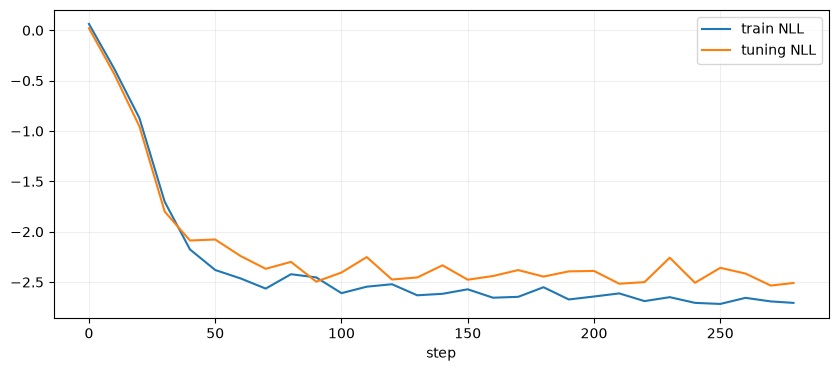

In [3]:
class GaussianInverse(nn.Module):
    def __init__(self):
        super().__init__(); self.net=nn.Sequential(nn.Linear(12,64),nn.SiLU(),nn.Linear(64,64),nn.SiLU(),nn.Linear(64,6))
    def forward(self,x):
        raw=self.net(x); return torch.cat([raw[:,:3],.02+torch.nn.functional.softplus(raw[:,3:])],1)
def nll(output,target):
    mu,sigma=output[:,:3],output[:,3:]
    return (.5*((target-mu)/sigma).square()+torch.log(sigma)).mean()
seed_all(9); model=GaussianInverse()
history=fit(model,normx(x),normy(y),normx(xv),normy(yv),steps=280,lr=.003,loss_fn=nll)
plt.plot(history[:,0],history[:,1],label='train NLL'); plt.plot(history[:,0],history[:,2],label='tuning NLL'); plt.xlabel('step'); plt.legend(); plt.show()

## 3. Calibrate intervals on a separate set
For each parameter, score absolute error divided by predicted scale. Use the finite-sample split-conformal rank $\lceil(n+1)0.9\rceil$. This gives marginal 90% coverage under exchangeability with calibration shots; it is not conditional coverage for every regime or simultaneous coverage of all parameters. Shifted physics breaks that assumption.

In [4]:
with torch.no_grad():
    pc=model(normx(xc)); score=(normy(yc)-pc[:,:3]).abs()/pc[:,3:]
rank=int(np.ceil((len(xc)+1)*.9)); multiplier=score.sort(dim=0).values[min(rank,len(xc))-1]
print('90% calibration multipliers:',multiplier.tolist())
def evaluate_inverse(xx,yy):
    with torch.no_grad(): p=model(normx(xx))
    mu=p[:,:3]*span+lo; width=multiplier*p[:,3:]*span
    covered=(yy[:,:3]-mu).abs()<=width
    return {'MAE':(yy[:,:3]-mu).abs().mean(0).tolist(),'coverage90':covered.float().mean(0).tolist(),
            'mean_width90':(2*width).mean(0).tolist()},mu,width
matched,mu,width=evaluate_inverse(xe,ye); shifted,mus,ws=evaluate_inverse(xshift,yshift)
print('Matched:',matched); print('Changed coupling + thermal loss:',shifted)
prior_mae=(ye[:,:3]-(lo+span/2)).abs().mean(0)
print('Prior-midpoint baseline MAE:',prior_mae.tolist())

90% calibration multipliers: [1.6588321924209595, 1.853328824043274, 1.9681823253631592]
Matched: {'MAE': [0.007762310095131397, 0.035951100289821625, 0.008461596444249153], 'coverage90': [0.9140625, 0.890625, 0.859375], 'mean_width90': [0.03281395882368088, 0.14615212380886078, 0.03637887164950371]}
Changed coupling + thermal loss: {'MAE': [0.01082792691886425, 0.3508770763874054, 0.018458392471075058], 'coverage90': [0.7265625, 0.0, 0.390625], 'mean_width90': [0.03173793479800224, 0.10485351085662842, 0.030296288430690765]}
Prior-midpoint baseline MAE: [0.10664784908294678, 0.14385345578193665, 0.04658207669854164]


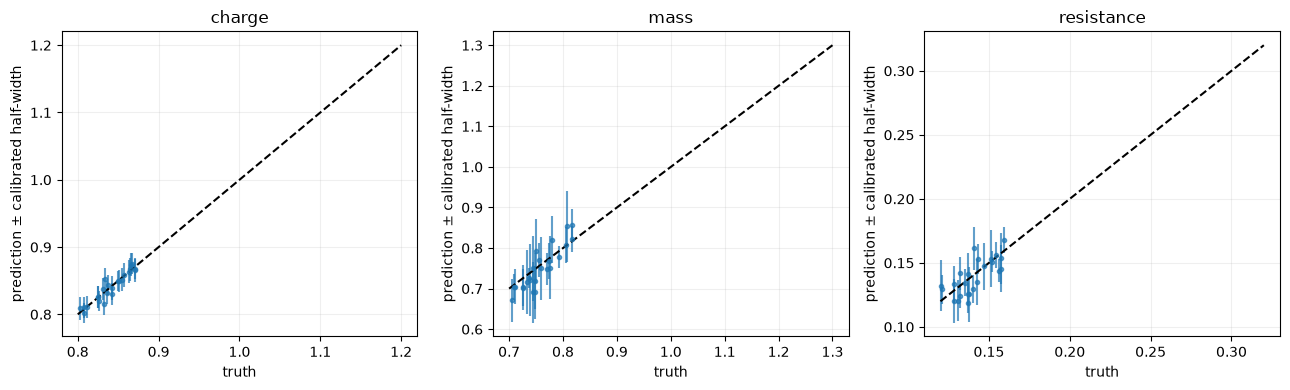

In [5]:
fig,axes=plt.subplots(1,3,figsize=(13,4))
for j,ax in enumerate(axes):
    order=torch.argsort(ye[:,j])[:24]
    ax.errorbar(ye[order,j],mu[order,j],yerr=width[order,j],fmt='.',alpha=.7)
    ax.plot([LOW[j],HIGH[j]],[LOW[j],HIGH[j]],'k--'); ax.set(title=PARAM_NAMES[j],xlabel='truth',ylabel='prediction ± calibrated half-width')
plt.tight_layout(); plt.show()

### Visual lab — How calibration chooses an interval multiplier

The calibration scores are absolute errors divided by the network's predicted scale. The vertical line marks the chosen multiplier; the horizontal line marks 90% of calibration examples. Each parameter gets its own multiplier.

**Notice:** calibration uses separate shots. Adjusting the multiplier until evaluation coverage looks good would use the evaluation set for fitting.

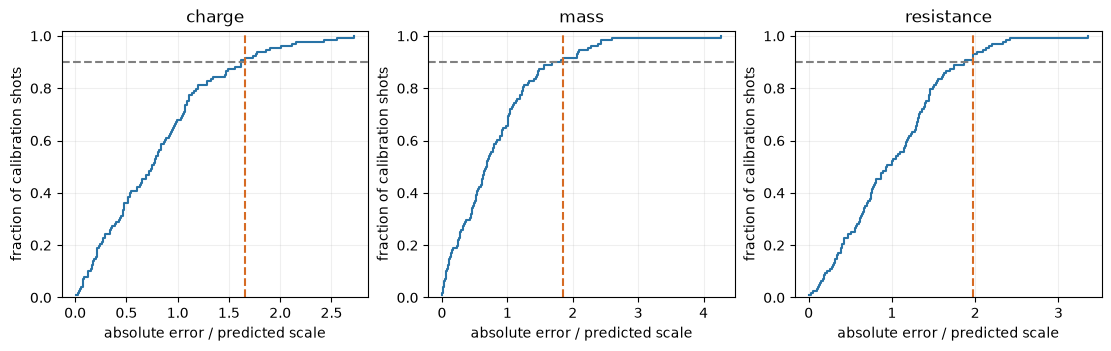

In [6]:
v_fig,v_axes=plt.subplots(1,3,figsize=(11,3.4),layout='constrained')
for v_j,v_ax in enumerate(v_axes):
    v_scores=np.sort(score[:,v_j].numpy()); v_fraction=np.arange(1,len(v_scores)+1)/len(v_scores)
    v_ax.step(v_scores,v_fraction,where='post',color='#2873a6')
    v_ax.axhline(.9,color='gray',ls='--'); v_ax.axvline(float(multiplier[v_j]),color='#d66b24',ls='--')
    v_ax.set(title=PARAM_NAMES[v_j],xlabel='absolute error / predicted scale',ylabel='fraction of calibration shots',ylim=(0,1.02))
plt.show()

## 4. Check coverage and sharpness together
An interval that always spans the whole prior may cover well but teach us little. A narrow interval that misses is overconfident. The mismatch evaluation changes the forward model without changing the parameter range; this tests a different failure from simple parameter extrapolation.

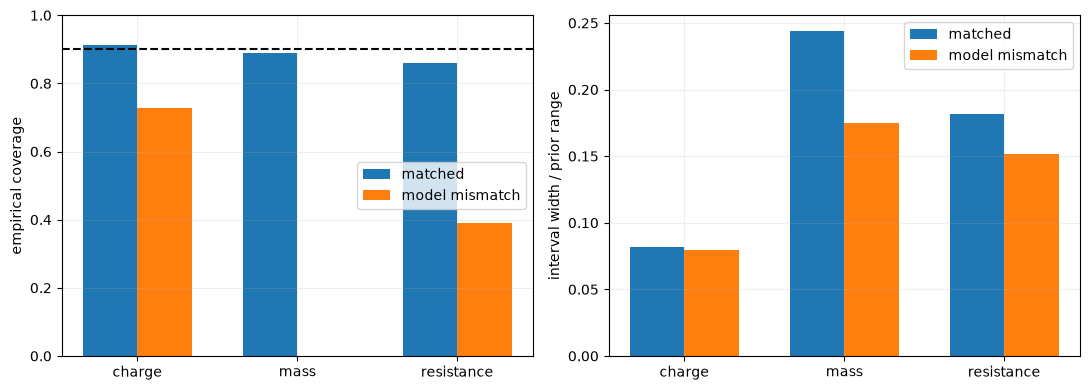

/Users/operator/Desktop/Factor/runs/world-model/09-3eba260333


In [7]:
fig,axes=plt.subplots(1,2,figsize=(11,4)); pos=np.arange(3)
for offset,stats,label in [(-.17,matched,'matched'),(.17,shifted,'model mismatch')]:
    axes[0].bar(pos+offset,stats['coverage90'],width=.34,label=label)
    axes[1].bar(pos+offset,np.array(stats['mean_width90'])/span.numpy(),width=.34,label=label)
axes[0].axhline(.9,color='k',ls='--'); axes[0].set(ylim=(0,1),ylabel='empirical coverage')
axes[1].set(ylabel='interval width / prior range')
for ax in axes: ax.set_xticks(pos,PARAM_NAMES[:3]); ax.legend()
plt.tight_layout(); plt.show()
run=save_run(ROOT,'09',{'matched':matched,'model_mismatch':shifted,'prior_midpoint_MAE':prior_mae.tolist(),'calibration_multiplier':multiplier.tolist()},
             {'train':384,'tuning':96,'calibration':128,'evaluation':128,'steps':280})
torch.save({'state_dict':model.state_dict(),'xmean':xmean,'xscale':xscale,'lo':lo,'span':span,'multiplier':multiplier},run/'inverse_model.pt')
print(run)

### Visual lab — See individual uncertainty failures

Each horizontal line is a calibrated mass interval for one evaluation shot, plotted as an error relative to that shot's true mass. **Blue** intervals cross zero; **orange** intervals miss. All 128 shots contribute to the reported coverage; the figure shows the first 24 without selecting favorable cases.

**Notice:** narrow intervals under changed physics can be confidently wrong. Width alone is not a measure of usefulness.

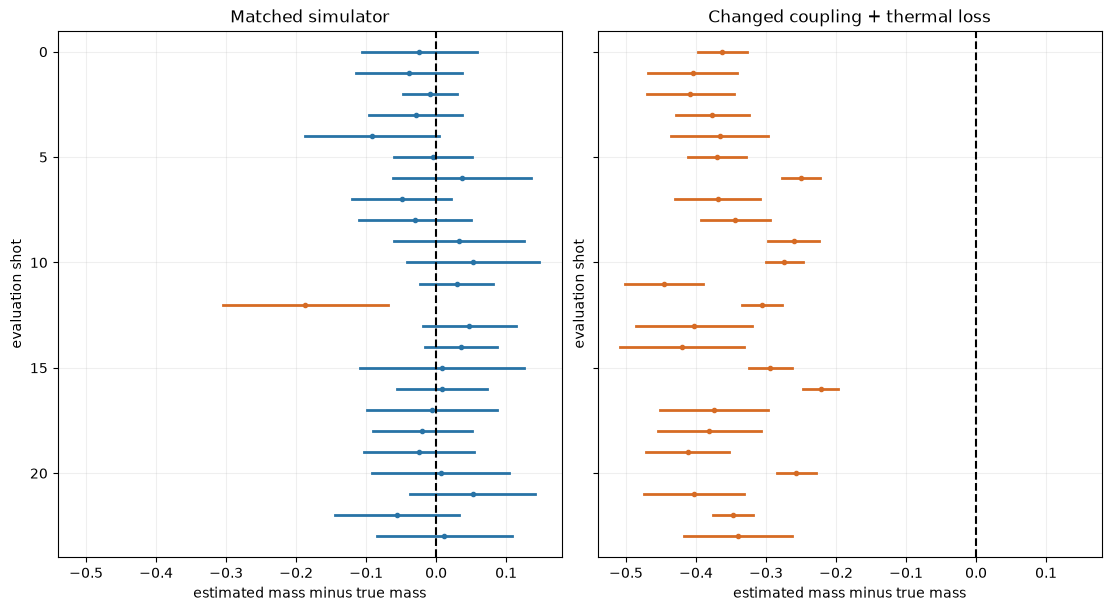

In [8]:
v_fig,v_axes=plt.subplots(1,2,figsize=(11,6),sharex=True,sharey=True,layout='constrained')
for v_ax,v_mu,v_width,v_truth,v_title in zip(v_axes,[mu,mus],[width,ws],[ye,yshift],['Matched simulator','Changed coupling + thermal loss']):
    v_errors=(v_mu[:24,1]-v_truth[:24,1]).numpy(); v_half=v_width[:24,1].numpy()
    for v_i,(v_error,v_h) in enumerate(zip(v_errors,v_half)):
        v_color='#2873a6' if abs(v_error)<=v_h else '#d66b24'
        v_ax.plot([v_error-v_h,v_error+v_h],[v_i,v_i],color=v_color,lw=2)
        v_ax.plot(v_error,v_i,'o',color=v_color,ms=3)
    v_ax.axvline(0,color='black',ls='--'); v_ax.set(title=v_title,xlabel='estimated mass minus true mass',ylabel='evaluation shot',ylim=(24,-1))
plt.show()

## Your next experiments

Write a prediction, change one thing, and save both successes and failures.

1. Replace the diagonal Gaussian with a Cholesky covariance head and visualize correlations.
2. Stratify coverage by charge quartile; marginal coverage may hide a weak region.
3. Train on multiple forward-model families and compare interval width and mismatch coverage.